In [4]:
%matplotlib inline
import os,sys,time
os.environ["OMP_NUM_THREADS"] = "1" # TODO: Figure out why tight coupling doesn't work with paraellization
import numpy as np
from math import pi
from copy import deepcopy as dcopy
#############################################
## MATPLOTLIB FEATURES
%matplotlib inline
import matplotlib 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
font = {'weight' : 'bold','size'   : 22}
mpl.rc('font', **font)
mpl.rc('font',   size=209)  #set defaults so that the plots are readable
mpl.rc('axes',   titlesize=20, labelsize=20)
mpl.rc('xtick',  labelsize=20)
mpl.rc('ytick',  labelsize=20)
mpl.rc('legend', fontsize =20)
mpl.rc('figure', titlesize=20)
mpl.rc('text',   usetex=True)
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

In [5]:
def mgrid(plt):
        plt.grid(linestyle='-', which='major', linewidth=0.5 , color='grey', alpha = 0.2)
        plt.grid(linestyle=':', which='minor', linewidth=0.5 , color='grey', alpha = 0.2)

In [6]:
# If you need to work with seperate instances of CLASS

class_path = '/data/AMARINS/nuCLASS'
classy_path = ''
for elem in os.listdir(os.path.join(
        class_path, "python", "build")):
    if elem.find("lib.") != -1:
        classy_path = os.path.join(
            class_path, "python", "build", elem)
    if len(classy_path)==1:
        classy_path = classy_path[0]
    else:
        stringcheck = "%i.%i"%(sys.version_info.major,sys.version_info.minor)
        for path in classy_path:
            if stringcheck in path:
                classy_path = path
                break

# Inserting the previously found path into the list of folders to
# search for python modules.
sys.path.insert(1, classy_path)
try:
    from classy import Class
    from classy import CosmoComputationError
except ImportError:
    print('Error: Could not import Classy.')

    
M = Class()
sys.path.remove(classy_path)
del Class
del sys.modules['classy']

In [7]:
common_settings = {
                   'output': 'tCl,pCl,lCl,mPk',
                   'h':0.67556,
                   'omega_b':0.02238280,   
                   'omega_cdm':0.1201075,  
                   'A_s':2.215e-9,
                   'n_s':0.9619,
                   'tau_reio':0.05430842,
                   'YHe':'BBN',
                   'l_max_scalars':6000,
                   'k_output_values': '1, 0.1, 0.01, 0.001',
                    #'z_max_pk':100,
                   'P_k_max_1/Mpc':200.0,
                   'gauge':'sync',
                   'lensing':'yes',
                   'N_ur' : 0.00441,
                   'N_ncdm' : 1,
                   'm_ncdm' : 0.02,
                   'deg_ncdm' : 3,
                   'has_cmb_chi_window_shift': 'no',
                   #'cmb_chi_shift_epsilon': 0.01,
                   #'cmb_chi_shift_zcut': 50.0,
                   #'cmb_chi_shift_dz': 10.0,
                   'Omega_k': 0    
}


common_settings_2 = {
                   'output': 'tCl,pCl,lCl,mPk',
                   'h':0.67556,
                   'omega_b':0.02238280,   
                   'omega_cdm':0.1201075,  
                   'A_s':2.215e-9,
                   'n_s':0.9619,
                   'tau_reio':0.05430842,
                   'YHe':'BBN',
                   'l_max_scalars':6000,
                   'k_output_values': '1, 0.1, 0.01, 0.001',
                   #'z_max_pk':100,
                   'P_k_max_1/Mpc':200.0,
                   'gauge':'sync',
                   'lensing':'yes',
                   'N_ur' : 0.00441,
                   'N_ncdm' : 1,
                   'm_ncdm' : 0.02,
                   'deg_ncdm' : 3,
                   'has_cmb_chi_window_shift': 'yes',
                   'cmb_chi_shift_epsilon': 0.005,
                   'cmb_chi_shift_zcut': 50.0,
                   'cmb_chi_shift_dz': 10.0,
                   'Omega_k': 0    
}

In [8]:
klist = np.logspace(-4,np.log10(common_settings['P_k_max_1/Mpc']),1000)
def cl_pk(cset = None, Nur = 0, m_ncdm = 0.02, log10_G_eff = None, N_ncdm = 1, deg_ncdm = 3, Omega0_m = 0.3136284):
    M.empty()
    M.set(cset) 
    M.set({'N_ur' : Nur, 'N_ncdm' : N_ncdm, 'deg_ncdm':deg_ncdm, 'm_ncdm':m_ncdm})
    M.compute()
    om0_cdm_adj = Omega0_m*M.h()**2 - M.omega_b() - M.Omega_nu*M.h()**2
    M.empty()
    M.set(cset)
    M.set({'omega_cdm':om0_cdm_adj})
    M.set({'N_ur' : Nur, 'N_ncdm' : N_ncdm, 'deg_ncdm':deg_ncdm, 'm_ncdm':m_ncdm})
    # M.set({"ncdm_nuself_fluid_trigger_tau_c_over_tau_h":1.0e-8})
    # M.set({"ncdm_nuself_trigger_tau_c_over_tau_h":1.0e3})
    # M.set({'tol_perturbations_integration':5e-5})
    # M.set({'ncdm_nuself_fluid_trigger_tau_c_over_tau' : 1e5})
    if log10_G_eff != None:
        M.set({'log10_G_eff' : log10_G_eff,'nuself_type' : 'massive'})
    M.compute()
    try:
        nucl = M.lensed_cl()
    except:
        nucl = M.raw_cl()
    nucl_raw = M.raw_cl()
    pnu = []
    for k in klist:
        pnu.append(M.pk(k,0))
    pnu = np.array(pnu)
    print(M.Omega0_m())
    return [nucl,nucl_raw,pnu]

In [9]:
fac = np.sqrt(1) # To benchmark with Vivian's code
# mlist = [0.06/3]
mlist = [0.06/3,0.23/3]
lgefflist  = [None,-2.0+np.log10(fac),-4.0+np.log10(fac)]
# lgefflist  = [None,-4.0+np.log10(fac),-6.0+np.log10(fac)]
# lgefflist  = [None,-4.0+np.log10(fac)]
cll = ['k','deepskyblue', 'r']
lsl = ['-','--']

In [10]:
log10Geff = -2.5
common_settings_2['cmb_chi_shift_epsilon']=0.02
clpk0 = cl_pk(cset=common_settings, m_ncdm = 0.02,  Nur=0, N_ncdm = 1, deg_ncdm = 3, log10_G_eff = None)
cl_0 = clpk0[0]

clpk1 = cl_pk(cset=common_settings, m_ncdm = 0.02,  Nur=0, N_ncdm = 1, deg_ncdm = 3, log10_G_eff = log10Geff)
cl_sinu = clpk1[0]

clpk2 = cl_pk(cset=common_settings_2, m_ncdm = 0.02,  Nur=0, N_ncdm = 1, deg_ncdm = 3, log10_G_eff = None)
cl_shift = clpk2[0]

clpk3 = cl_pk(cset=common_settings_2, m_ncdm = 0.02,  Nur=0, N_ncdm = 1, deg_ncdm = 3, log10_G_eff = log10Geff)
cl_sinushift = clpk3[0]

#common_settings_2['cmb_chi_shift_epsilon']=-common_settings_2['cmb_chi_shift_epsilon']
#clpk = cl_pk(cset=common_settings_2, m_ncdm = 0.02,  Nur=0, N_ncdm = 1, deg_ncdm = 3, log10_G_eff = None)
#cl_shift_minus = clpk[0]

0.31362710980440306
0.31362710980440306
0.31362710980440306
0.31362710980440306


In [14]:
common_settings_2['cmb_chi_shift_epsilon']=-common_settings_2['cmb_chi_shift_epsilon']
clpk = cl_pk(cset=common_settings_2, m_ncdm = 0.02,  Nur=0, N_ncdm = 1, deg_ncdm = 3, log10_G_eff = None)
cl_shift_minus = clpk[0]

0.31362710980440306


/tmp/ipykernel_989274/2250184392.py:31: RuntimeWarning: invalid value encountered in divide
  ax.plot(ell[2:], (cl_sinu[T] /cl_0[T]     - 1)[2:], color='blue'  , ls='solid' ,lw=2.4)
/tmp/ipykernel_989274/2250184392.py:32: RuntimeWarning: invalid value encountered in divide
  ax.plot(ell[2:], (cl_shift[T]/cl_0[T]     - 1)[2:], color='red'   , ls='dashed',lw=1.4)
/tmp/ipykernel_989274/2250184392.py:33: RuntimeWarning: invalid value encountered in divide
  ax.plot(ell[2:], (cl_sinushift[T]/cl_0[T] - 1)[2:], color='orange', ls='dashed',lw=1.0)


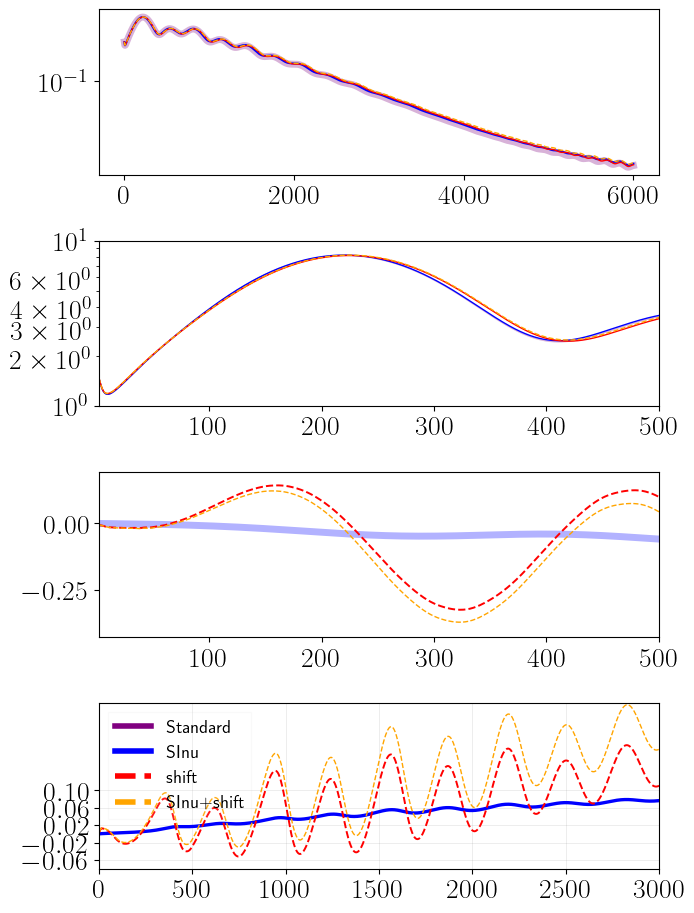

In [17]:
T = 'tt'

fig   = plt.figure()
grid  = plt.GridSpec(4,1,top=1.9,right=1,wspace=0.3, hspace=0.4)
ax    = plt.subplot(grid[0,0])                  
ell = cl_0['ell']
fact = ell*(ell+1)/2/np.pi/1e-10

ax.semilogy(ell[2:], (fact*cl_0[T])[2:], color='purple', ls='solid',lw=5, alpha=0.3)
ax.semilogy(ell[2:], (fact*cl_sinu[T])[2:], color='blue', ls='solid',lw=1.4)
ax.semilogy(ell[2:], (fact*cl_shift[T])[2:], color='red', ls='solid',lw=1.0)
ax.semilogy(ell[2:], (fact*cl_sinushift[T])[2:], color='orange', ls='dashed',lw=1.0)

ax    = plt.subplot(grid[1,0])                  
ax.semilogy(ell[2:], (fact*cl_0[T])[2:], color='purple', ls='solid',lw=1, alpha=0.3)
ax.semilogy(ell[2:], (fact*cl_sinu[T])[2:], color='blue', ls='solid',lw=1.0)
ax.semilogy(ell[2:], (fact*cl_shift[T])[2:], color='red', ls='solid',lw=1.0)
ax.semilogy(ell[2:], (fact*cl_sinushift[T])[2:], color='orange', ls='dashed',lw=1.0)
ax.set_xlim([2,500]) 
ax.set_ylim([1e0,1e1]) 

ax    = plt.subplot(grid[2,0])                  
ax.plot(ell[2:], (fact*(cl_0[T]-cl_sinu[T]))[2:], color='blue', ls='solid',lw=5.0, alpha=0.3)
ax.plot(ell[2:], (fact*(cl_0[T]-cl_shift[T]))[2:]  , color='red', ls='dashed',lw=1.4)
ax.plot(ell[2:], (fact*(cl_0[T]-cl_sinushift[T]))[2:]  , color='orange', ls='dashed',lw=1.0)
ax.set_xlim([2,500]) 
#ax.set_ylim([1e0,1e1]) 


ax    = plt.subplot(grid[3,0])                  
ax.plot(ell[2:], (cl_sinu[T] /cl_0[T]     - 1)[2:], color='blue'  , ls='solid' ,lw=2.4)
ax.plot(ell[2:], (cl_shift[T]/cl_0[T]     - 1)[2:], color='red'   , ls='dashed',lw=1.4)
ax.plot(ell[2:], (cl_sinushift[T]/cl_0[T] - 1)[2:], color='orange', ls='dashed',lw=1.0)
#ax.plot(ell[2:], (cl_shift_minus[T]/cl_0[T] - 1)[2:], color='green', ls='solid',lw=1.4)
ax.set_xlim([0,3000]) 
ax.set_ylim([-0.08,0.3])
mgrid(plt)
ax.set_yticks([-0.06,-0.02,0.02,0.06,0.1])
###########################################################
custom_lines = [Line2D([], [], color='purple' , linewidth=4, linestyle='solid' ),
                Line2D([], [], color='blue'   , linewidth=4, linestyle='solid' ),
                Line2D([], [], color='red'    , linewidth=4, linestyle='dashed'),                
                Line2D([], [], color='orange' , linewidth=4, linestyle='dashed'),                                
               ]
legend = ax.legend(custom_lines, [r'Standard', r'SInu', r'shift', r'SInu+shift'],#title='LSST',
                   ncols=1, fontsize=13, loc='upper left',framealpha=0.1, fancybox=False,
                   # bbox_to_anchor=(0.70, 0.65),  shadow=False,
                  )#edgecolor='lightblue', 
plt.show();

/tmp/ipykernel_989274/838366912.py:31: RuntimeWarning: invalid value encountered in divide
  ax.plot(ell[2:], (cl_sinu[T] /cl_0[T]     - 1)[2:], color='blue'  , ls='solid' ,lw=2.4)
/tmp/ipykernel_989274/838366912.py:32: RuntimeWarning: invalid value encountered in divide
  ax.plot(ell[2:], (cl_shift[T]/cl_0[T]     - 1)[2:], color='red'   , ls='dashed',lw=1.4)
/tmp/ipykernel_989274/838366912.py:33: RuntimeWarning: invalid value encountered in divide
  ax.plot(ell[2:], (cl_sinushift[T]/cl_0[T] - 1)[2:], color='orange', ls='dashed',lw=1.0)


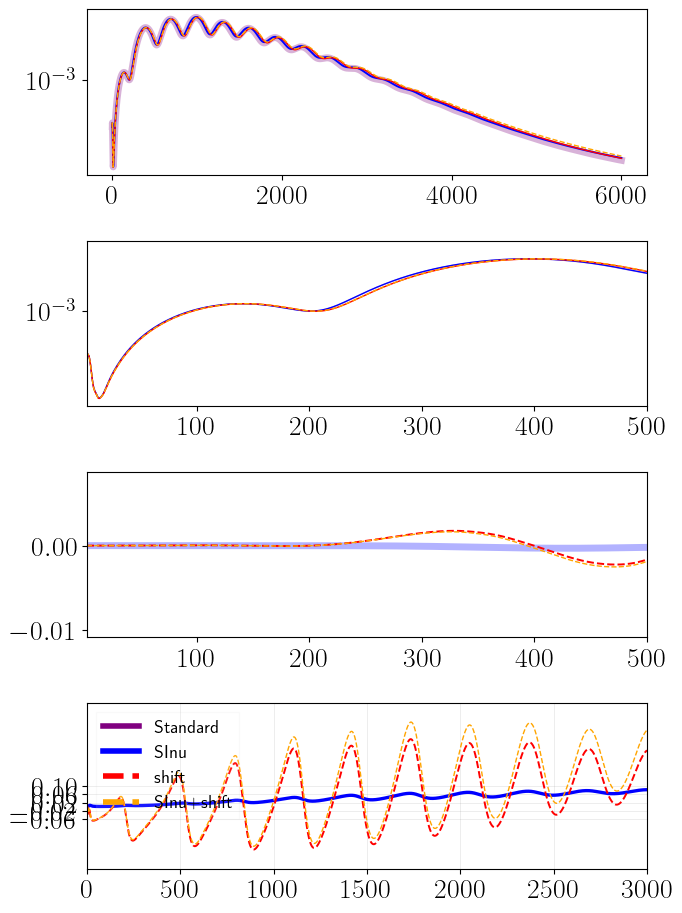

In [18]:
T = 'ee'

fig   = plt.figure()
grid  = plt.GridSpec(4,1,top=1.9,right=1,wspace=0.3, hspace=0.4)
ax    = plt.subplot(grid[0,0])                  
ell = cl_0['ell']
fact = ell*(ell+1)/2/np.pi/1e-10

ax.semilogy(ell[2:], (fact*cl_0[T])[2:], color='purple', ls='solid',lw=5, alpha=0.3)
ax.semilogy(ell[2:], (fact*cl_sinu[T])[2:], color='blue', ls='solid',lw=1.4)
ax.semilogy(ell[2:], (fact*cl_shift[T])[2:], color='red', ls='solid',lw=1.0)
ax.semilogy(ell[2:], (fact*cl_sinushift[T])[2:], color='orange', ls='dashed',lw=1.0)

ax    = plt.subplot(grid[1,0])                  
ax.semilogy(ell[2:], (fact*cl_0[T])[2:], color='purple', ls='solid',lw=1, alpha=0.3)
ax.semilogy(ell[2:], (fact*cl_sinu[T])[2:], color='blue', ls='solid',lw=1.0)
ax.semilogy(ell[2:], (fact*cl_shift[T])[2:], color='red', ls='solid',lw=1.0)
ax.semilogy(ell[2:], (fact*cl_sinushift[T])[2:], color='orange', ls='dashed',lw=1.0)
ax.set_xlim([2,500]) 
#ax.set_ylim([1e0,1e1]) 

ax    = plt.subplot(grid[2,0])                  
ax.plot(ell[2:], (fact*(cl_0[T]-cl_sinu[T]))[2:], color='blue', ls='solid',lw=5.0, alpha=0.3)
ax.plot(ell[2:], (fact*(cl_0[T]-cl_shift[T]))[2:]  , color='red', ls='dashed',lw=1.4)
ax.plot(ell[2:], (fact*(cl_0[T]-cl_sinushift[T]))[2:]  , color='orange', ls='dashed',lw=1.0)
ax.set_xlim([2,500]) 
#ax.set_ylim([1e0,1e1]) 


ax    = plt.subplot(grid[3,0])                  
ax.plot(ell[2:], (cl_sinu[T] /cl_0[T]     - 1)[2:], color='blue'  , ls='solid' ,lw=2.4)
ax.plot(ell[2:], (cl_shift[T]/cl_0[T]     - 1)[2:], color='red'   , ls='dashed',lw=1.4)
ax.plot(ell[2:], (cl_sinushift[T]/cl_0[T] - 1)[2:], color='orange', ls='dashed',lw=1.0)
#ax.plot(ell[2:], (cl_shift_minus[T]/cl_0[T] - 1)[2:], color='green', ls='solid',lw=1.4)
ax.set_xlim([0,3000]) 
ax.set_ylim([-0.3,0.5])
mgrid(plt)
ax.set_yticks([-0.06,-0.02,0.02,0.06,0.1])
###########################################################
custom_lines = [Line2D([], [], color='purple' , linewidth=4, linestyle='solid' ),
                Line2D([], [], color='blue'   , linewidth=4, linestyle='solid' ),
                Line2D([], [], color='red'    , linewidth=4, linestyle='dashed'),                
                Line2D([], [], color='orange' , linewidth=4, linestyle='dashed'),                                
               ]
legend = ax.legend(custom_lines, [r'Standard', r'SInu', r'shift', r'SInu+shift'],#title='LSST',
                   ncols=1, fontsize=13, loc='upper left',framealpha=0.1, fancybox=False,
                   # bbox_to_anchor=(0.70, 0.65),  shadow=False,
                  )#edgecolor='lightblue', 
plt.show();

/tmp/ipykernel_989274/3162968646.py:16: RuntimeWarning: invalid value encountered in divide
  ax.plot(ell[2:], (cl_0[T]/cl_0[T])[2:], color='blue', ls='solid',lw=2.4, label='SInu')
/tmp/ipykernel_989274/3162968646.py:17: RuntimeWarning: invalid value encountered in divide
  ax.plot(ell[2:], (  cl_shift[T]/cl_0[T])[2:], color='red', ls='solid',lw=1.4 , label='SInu + shift')


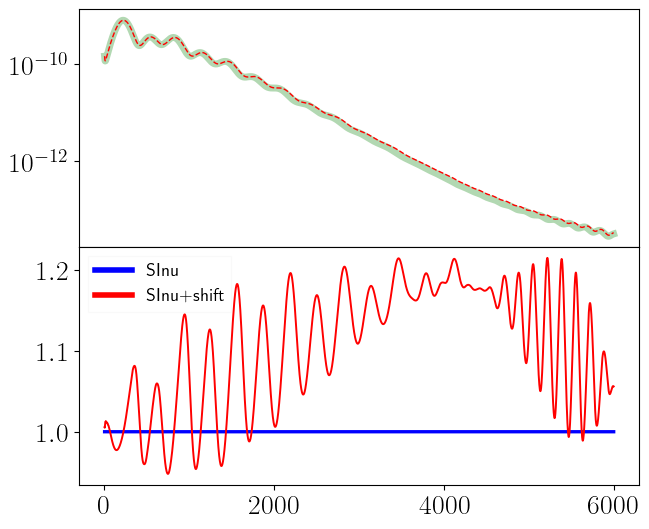

In [24]:
T = 'tt'

fig   = plt.figure()
grid  = plt.GridSpec(2,1,top=1.1,right=1,wspace=0.3, hspace=0.0)
ax    = plt.subplot(grid[0,0])                  
ell = cl_0['ell']
f = (1+common_settings_2['cmb_chi_shift_epsilon'])
ellp = ell*f
fact = ell*(ell+1)/2/np.pi
factp = ellp*(ellp+1)/2/np.pi#*(f**2)
ax.semilogy(ell[2:], (fact*cl_0[T])[2:], color='green', ls='solid',lw=5, alpha=0.3)
#ax.semilogy(ell[2:], (fact*cl_0[T])[2:], color='blue', ls='solid',lw=1.4)
ax.semilogy(ell[2:], (fact*cl_shift[T])[2:], color='red', ls='dashed',lw=1.0)

ax    = plt.subplot(grid[1,0])                  
ax.plot(ell[2:], (cl_0[T]/cl_0[T])[2:], color='blue', ls='solid',lw=2.4, label='SInu')
ax.plot(ell[2:], (  cl_shift[T]/cl_0[T])[2:], color='red', ls='solid',lw=1.4 , label='SInu + shift')
#ax.plot(ellp[2:], ( (factp/fact)* cl_0[T]/cl_0[T])[2:], color='black', ls='dashed',lw=1.0 , label='SInu + shift')
###########################################################
custom_lines = [Line2D([], [], color='blue'  , linewidth=4, linestyle='solid'),
                Line2D([], [], color='red'   , linewidth=4, linestyle='solid'),
               ]
legend = ax.legend(custom_lines, [r'SInu', r'SInu+shift'],#title='LSST',
                   ncols=1, fontsize=13, loc='upper left',framealpha=0.1, fancybox=False,
                  # bbox_to_anchor=(0.70, 0.65),  shadow=False,
                  )#edgecolor='lightblue', 
plt.show();